In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

In [62]:
def preprocess_data(data):
    df= data.copy()

    df.drop(columns=['PatientID'])

    return df

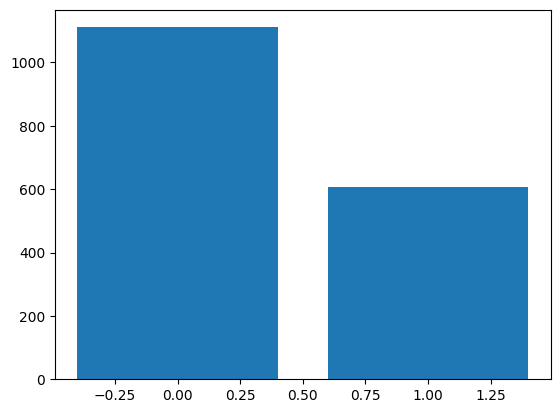

In [63]:
from sklearn.model_selection import train_test_split

train_df= pd.read_csv('train.csv')
test_df= pd.read_csv('test.csv')

X= preprocess_data(train_df.drop(columns=['Diagnosis']))
y= train_df['Diagnosis']

X_train, X_eval, y_train, y_eval= train_test_split(X, y, train_size=0.8, stratify= y, random_state= seed)

X_test= preprocess_data(test_df)

plt.bar(y.value_counts().index, y.value_counts().values)
plt.show()

In [64]:
# Subtask 1

answer1= pd.DataFrame([{
    'subtaskID': 1,
    'datapointID': f"{row['PatientID']:.0f}",
    'answer': len(train_df[train_df['Age'] == row['Age']])
} for _,row in test_df.iterrows()])

answer1.head()

,subtaskID,datapointID,answer
0,1,5202,44
1,1,6831,66
2,1,6407,50
3,1,5821,64
4,1,5581,56


In [65]:
# Subtask 2

answer2= pd.DataFrame([{
    'subtaskID': 2,
    'datapointID': f"{row['PatientID']:.0f}",
    'answer': train_df[train_df['Age'] == row['Age']]['Smoking'].value_counts().loc[1] / len(train_df[train_df['Age'] == row['Age']]) * 100
} for _,row in test_df.iterrows()])

answer2.head()

,subtaskID,datapointID,answer
0,2,5202,34.090909
1,2,6831,30.303030
2,2,6407,24.000000
3,2,5821,15.625000
4,2,5581,28.571429


In [66]:
# Subtask 3
from catboost import CatBoostClassifier

cat_cols= X.select_dtypes(include=['object', 'str']).columns.to_list()

model= CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    cat_features=cat_cols,
    auto_class_weights="Balanced",
    early_stopping_rounds=200,
    random_state= seed,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_eval, y_eval)],
    verbose= 200
)

predictions= model.predict(X_test)


0:	learn: 0.6538539	test: 0.6551899	best: 0.6551899 (0)	total: 2.84ms	remaining: 8.51s
200:	learn: 0.0511107	test: 0.1339003	best: 0.1339003 (200)	total: 373ms	remaining: 5.2s
400:	learn: 0.0173949	test: 0.1281532	best: 0.1281451 (399)	total: 749ms	remaining: 4.86s
600:	learn: 0.0088402	test: 0.1293612	best: 0.1276269 (415)	total: 1.12s	remaining: 4.46s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.1276268801
bestIteration = 415

Shrink model to first 416 iterations.


In [67]:
answer3= pd.DataFrame([{
    'subtaskID': 3,
    'datapointID': id_,
    'answer': pred
} for id_, pred in zip(test_df['PatientID'], predictions)])

answer3.head()

,subtaskID,datapointID,answer
0,3,5202,1
1,3,6831,0
2,3,6407,1
3,3,5821,1
4,3,5581,1


In [68]:
answer= pd.concat([answer1, answer2, answer3])
answer.to_csv("submission.csv", index= False)